# Character Limits: A Technical Case Study of Reverse-Engineering and  Fan-Translating Japanese Visual Novels on the Game Boy Advance

 ### Ian  Hunter [![orcid](https://orcid.org/sites/default/files/images/orcid_16x16.png)](https://orcid.org/0000-0003-3408-8138) 
Unaffiliated

[![cc-by](https://licensebuttons.net/l/by/4.0/88x31.png)](https://creativecommons.org/licenses/by/4.0/) 
©Ian . Published by De Gruyter in cooperation with the University of Luxembourg Centre for Contemporary and Digital History. This is an Open Access article distributed under the terms of the [Creative Commons Attribution License CC-BY](https://creativecommons.org/licenses/by/4.0/)


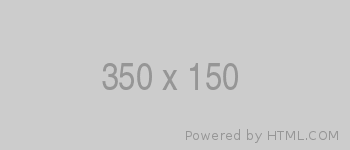

In [1]:
from IPython.display import Image, display

display(Image("./media/placeholder.png"))

Reverse Engineering, Translation, Game Boy Advance, GBA, ROM Hacking, Visual Novels, Digital Preservation, Fanslation, Retro Gaming, Fanslation, Fan Translation

Throughout video game history, many titles have only been released regionally, whether for cultural, financial or other reasons. This paper examines the niche field of hobbyist or otherwise unofficial translation and repackaging of these games, making them accessible to audiences previously unable to engage with the media. By providing a technical case study of such a game's localization using reverse engineering techniques, this paper explores a side of the field that has seen little academic attention, discusses the complexities associated with the activity and highlights the crucial role of such grassroots initiatives in the preservation of digital culture.

## Introduction

Nintendo's Game Boy Advance (GBA) was launched in 2001 and ceased production in 2010 (\cite{nintendo2024corporate}). Software sales continued for 2 more years before becoming a negligible amount in Nintendo's sales (\cite{NintendoSales}). Since then, there have been three further generations of game consoles, which game development companies have moved onto, with significantly more processing and graphics capabilities.

However, a small niche of development continues on the GBA. A handful of indie developers have released original games for the console well after 2012  --- e.g., Goodboy Galaxy was funded on Kickstarter in 2025, promising a GBA release (\cite{GoodboyGalaxy}). There is also a community of self-titled \enquote{ROM Hackers} (ROM here referring to the physical cartridges the games are stored on) who modify existing games to adapt, extend, and experiment with. 

A sub-group of these \enquote{ROM Hackers} are fan translators --- or as they are more commonly known in the sphere \enquote{fanslators}. Many GBA titles were released in only one language or a limited set of languages and never localized to other regions, excluding potential players. In Table \ref{tab:language-support}, we show the distribution of language support in the GBA games on the popular IGDB website. As can be seen, there is a sharp drop in non-English support, particularly outside Japanese and major European languages. With the discontinuation of the GBA ecosystem, most games are now unlikely to see an official new language release. By the fan translators unofficially translating these games, these games can reach a new audience. Despite the unlikelihood of official releases, GBA games are still under copyright in most jurisdictions, making much of the hobbyist work be of questionable legality. Initial legal cases such as the Nintendo vs GameGenie \cite{galoob1992nintendo} \enquote{cheat cartridge} case have shown that the act of reverse engineering and modification of console code is itself not inherently illegal. Many other aspects of the law have not been tested in court, as companies typically have focussed on activities that can be seen as a percieved commercial conflict (e.g. creating seperate 'level' packs for an active console was deemed an illegal derivative in the MicroStar vs FormGen case (\cite{microstar1998formgen})) and companies tend to prefer issuing takedown notices over costly legal battles (Such as the takedown request of the Metroid II remake project (\cite{machkovech2016metroid})).

Despite the focus on protecting active commercial interests, even during the GBA's lifetime, several bootleg copies of popular games have been sold with unofficial (and often questionable, as seen in Figure \ref{fig:pokemon_battle}) translations. Unlike the majority of the ROM-hacking community, which generally operates on a non-profit basis, these physical counterfeits represented a direct trademark and copyright violation that Nintendo actively pursued through coordinated seizures with government organizations. The correspondence between Nintendo and the International Intellectual Property Alliance (IIPA) \cite{nintendo2008special301} goes into great detail about the high volume of counterfeit cartridges, difficulties with differences in IP law and enforcement of such in other countries, and a set of recommended trade monitoring actions. These cartridges often included non-modified games that were illegally manufactured.

Much of the existing academic literature that discusses the practise of ROM Hacking and/or fanslation is often framed around this legal context, as well as cultural and societal aspects of the practise (see, for example, (\cite{Barnab2018BetweenFA}) and (\cite{feministhacking})). \cite{pablosanchez} provides a high-level overview of some techniques used by fan translators, but in this paper, we investigate at a deeper level through a practical case study of prototyping a reverse-engineered translation of a game, and review the challenges we faced. We review how the practice could be modernized and accellerated taking into account the last 20 years of innovation in computational advances.

While we will refer to other games, this research has been performed primarily on the Japanese visual novel game \enquote{ちょびっツ for GameboyAdvance -アタシだけのヒト-}, or in roman characters --- \enquote{Chobits: Atashi Dake no Hito} (Shortened to just \enquote{Chobits} for convenience for the rest of this paper). The methods in this work are independent of the actual title used.

This is a hermeneutic paragraph

Editor|1641|1798|1916
---|---|---|---
Senan|0.55|0.4|0.3
Henry|0.71|0.5|0.63

In [2]:
# Check your Python version
from platform import python_version
python_version()

#!python -V

'3.11.9'

In [7]:
# pandas package needs to be added to the requirements.txt 's file 
%pip install pandas
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 1.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.5/117.5 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 40.4 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 355.2/355.2 kB 16.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 53.1 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 38.9 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 53.7 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 122.8/122.8 kB 3.0 MB/s eta 0:00:00ta 0:00:01
Note: you may need to restart the kernel to use updated packages.


In [6]:
import pandas as pd
df = pd.read_csv("https://raw.githubusercontent.com/ianfhunter/gba-fanslation-sample/refs/heads/main/gba_language_distribution.csv")
df

,Language,Total,Percentage (%)
0,English,710,76.84
1,Japanese,326,35.28
2,French,97,10.50
3,German,97,10.50
4,Spanish (Spain),83,8.98
5,Italian,80,8.66
6,Dutch,43,4.65
7,Danish,15,1.62
8,Chinese (Simplified),14,1.52
9,Swedish,10,1.08


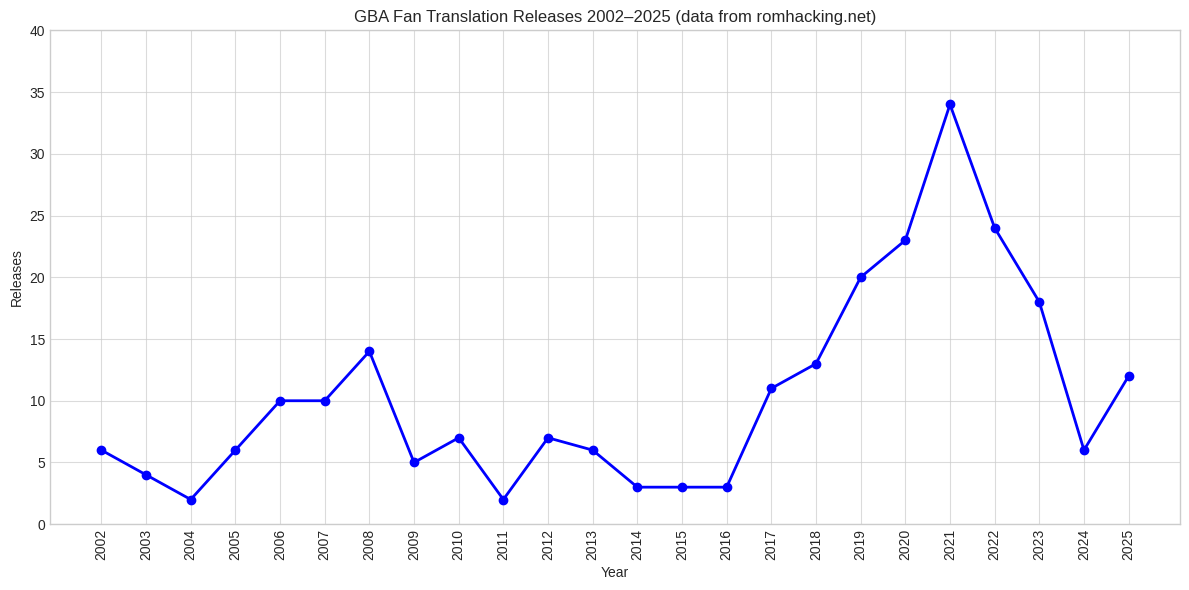

In [9]:
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')
# 1. Prepare the data
data = [
    (2002,6), (2003,4), (2004,2), (2005,6), (2006,10), (2007,10),
    (2008,14), (2009,5), (2010,7), (2011,2), (2012,7), (2013,6),
    (2014,3), (2015,3), (2016,3), (2017,11), (2018,13), (2019,20),
    (2020,23), (2021,34), (2022,24), (2023,18), (2024,6), (2025,12)
]

years, releases = zip(*data)

# 2. Create the plot
plt.figure(figsize=(12, 6))
plt.plot(years, releases, color='blue', marker='o', linewidth=2, markersize=6)

# 3. Apply TikZ-like styling
plt.xlabel('Year')
plt.ylabel('Releases')
plt.title('GBA Fan Translation Releases 2002–2025 (data from romhacking.net)')

# Set axis limits and ticks to match your LaTeX code
plt.ylim(0, 40)
plt.xticks(years, rotation=90)
plt.grid(True, linestyle='-', alpha=0.7)

# 4. Display
plt.tight_layout()
plt.show()

In [5]:
<!-- BIBLIOGRAPHY START -->
<div class="csl-bib-body">
</div>
<!-- BIBLIOGRAPHY END -->

SyntaxError: invalid syntax (1066700117.py, line 1)